[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SushrutGaikwad/svm-gmu/blob/main/experiments/gmu_vs_gsu_approximation.ipynb)

## Installing LaTeX on Google Colab

This is required if you want to save your plots in the `.pgf` format which LaTeX understands.

In [1]:
%%capture

!apt-get install -y texlive-xetex texlive-fonts-recommended cm-super

# Does the Gaussian Mixture Uncertainty Really Help?

This experiment compares SVM-GMU against SVM-GSU on the `close_separable` dataset to isolate the value of modeling uncertainty as a *mixture* of Gaussians rather than a single Gaussian. The question is simple: if we throw away the mixture structure and replace each GMM with its best single-Gaussian approximation, does the decision boundary change in a way that matters?

We approximate each sample's GMM by the Gaussian that shares its *overall* mean and covariance (moment-matched reduction). Concretely, for a GMM with weights $\pi_m$, means $\boldsymbol{\mu}_m$, and covariances $\boldsymbol{\Sigma}_m$, the moment-matched Gaussian has:

$$
\boldsymbol{\mu} \;=\; \sum_{m=1}^{M} \pi_m \boldsymbol{\mu}_m,
\qquad
\boldsymbol{\Sigma} \;=\; \underbrace{\sum_{m=1}^{M} \pi_m \boldsymbol{\Sigma}_m}_{\text{within-component}}
\;+\;
\underbrace{\sum_{m=1}^{M} \pi_m (\boldsymbol{\mu}_m - \boldsymbol{\mu})(\boldsymbol{\mu}_m - \boldsymbol{\mu})^{\intercal}}_{\text{between-component}}.
$$

The second identity is the *law of total covariance*: the total covariance of the mixture is the expected within-component covariance plus the covariance of the component means. The between-component term captures the spread that comes from the components sitting at different locations, which is precisely what lets a row of small components (a banana or crescent) turn into a large, oriented ellipse after moment-matching.

For this dataset the GMMs are banana- and crescent-shaped, so the moment-matched Gaussian is necessarily a very *lossy* approximation: a single ellipse cannot express curvature. We should therefore expect visible differences between the SVM-GMU and SVM-GSU boundaries, and those differences quantify what the mixture structure buys us.

**Note on implementation.** SVM-GSU is the same optimization as SVM-GMU restricted to single-component mixtures, so we reuse the `SvmGmu` class and simply pass a `sample_uncertainty` list whose entries each have one component of weight 1.

In [2]:
%%capture

# Installing svm-gmu
!pip install git+https://github.com/SushrutGaikwad/svm-gmu.git

## 1. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty

## 2. Dataset

We use the exact same 6-point banana/crescent dataset as `examples/close_separable.ipynb` and `experiments/svm_gmu_convergence.ipynb`.

In [4]:
X = np.array([
    [-1.8,  0.0],   # +1
    [-2.0,  1.5],   # +1
    [-1.0,  2.5],   # +1
    [ 1.5, -1.0],   # -1
    [ 1.0,  1.0],   # -1
    [ 2.0,  2.0],   # -1
])
y = np.array([+1, +1, +1, -1, -1, -1])


In [5]:
sample_1 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-4.2, -0.3],
        [-3.8,  0.3],
        [-3.0,  0.5],
        [-2.2,  0.3],
        [-1.8, -0.3],
    ]),
    "covariances": np.array([
        [[ 0.08, -0.05], [-0.05,  0.15]],
        [[ 0.10, -0.03], [-0.03,  0.12]],
        [[ 0.18,  0.00], [ 0.00,  0.06]],
        [[ 0.10,  0.03], [ 0.03,  0.12]],
        [[ 0.08,  0.05], [ 0.05,  0.15]],
    ]),
}

sample_2 = {
    "weights": np.array([0.08, 0.15, 0.22, 0.30, 0.15, 0.10]),
    "means": np.array([
        [-2.2,  0.6],
        [-1.8,  1.1],
        [-1.4,  1.5],
        [-0.8,  1.7],
        [-0.4,  1.5],
        [-0.1,  1.1],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04], [ 0.04,  0.13]],
        [[ 0.09,  0.03], [ 0.03,  0.10]],
        [[ 0.14,  0.02], [ 0.02,  0.07]],
        [[ 0.18,  0.00], [ 0.00,  0.05]],
        [[ 0.12, -0.02], [-0.02,  0.07]],
        [[ 0.08, -0.04], [-0.04,  0.12]],
    ]),
}

sample_3 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-0.6,  2.2],
        [-0.2,  2.7],
        [ 0.3,  3.0],
        [ 0.8,  3.4],
        [ 1.1,  3.8],
    ]),
    "covariances": np.array([
        [[ 0.14, -0.06], [-0.06,  0.08]],
        [[ 0.12, -0.07], [-0.07,  0.10]],
        [[ 0.10, -0.05], [-0.05,  0.14]],
        [[ 0.08,  0.03], [ 0.03,  0.16]],
        [[ 0.10,  0.06], [ 0.06,  0.15]],
    ]),
}

sample_4 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [-0.9, -0.3],
        [-0.5, -0.7],
        [-0.1, -1.0],
        [ 0.4, -1.2],
        [ 0.8, -1.1],
        [ 1.1, -0.8],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04], [ 0.04,  0.12]],
        [[ 0.09,  0.03], [ 0.03,  0.10]],
        [[ 0.15,  0.00], [ 0.00,  0.07]],
        [[ 0.15,  0.00], [ 0.00,  0.07]],
        [[ 0.09, -0.03], [-0.03,  0.10]],
        [[ 0.12, -0.05], [-0.05,  0.09]],
    ]),
}

sample_5 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [1.3,  0.7],
        [1.7,  0.3],
        [2.3,  0.1],
        [2.9,  0.3],
        [3.3,  0.7],
    ]),
    "covariances": np.array([
        [[ 0.09,  0.05], [ 0.05,  0.14]],
        [[ 0.12,  0.03], [ 0.03,  0.10]],
        [[ 0.16,  0.00], [ 0.00,  0.07]],
        [[ 0.12, -0.03], [-0.03,  0.10]],
        [[ 0.09, -0.05], [-0.05,  0.14]],
    ]),
}

sample_6 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [2.4,  2.3],
        [2.8,  2.0],
        [3.3,  2.0],
        [3.8,  2.1],
        [4.2,  2.5],
        [4.4,  3.0],
    ]),
    "covariances": np.array([
        [[ 0.08,  0.05], [ 0.05,  0.11]],
        [[ 0.12,  0.03], [ 0.03,  0.08]],
        [[ 0.15,  0.00], [ 0.00,  0.06]],
        [[ 0.13, -0.02], [-0.02,  0.07]],
        [[ 0.09, -0.04], [-0.04,  0.10]],
        [[ 0.07, -0.05], [-0.05,  0.12]],
    ]),
}

sample_uncertainty_gmu = [sample_1, sample_2, sample_3,
                      sample_4, sample_5, sample_6]

## 3. Moment-matched single-Gaussian approximation

For each sample's GMM we compute the overall mean and covariance using the formulas above, then build a new `sample_uncertainty` list whose entries each have a single component with weight 1. This list is the GSU-style input to the same `SvmGmu` estimator.

In [6]:
def moment_match_gmm(gmm: dict) -> dict:
    """Reduce a GMM to a single Gaussian with the same overall mean/cov.

    Parameters
    ----------
    gmm : dict
        Dict with keys 'weights' (shape (M,)), 'means' (shape (M, d)),
        'covariances' (shape (M, d, d)).

    Returns
    -------
    dict
        A single-component 'GMM' with weight 1, the mixture's overall
        mean, and the mixture's overall covariance (via the law of
        total covariance).
    """
    weights = np.asarray(gmm["weights"], dtype=np.float64)
    means = np.asarray(gmm["means"], dtype=np.float64)
    covs = np.asarray(gmm["covariances"], dtype=np.float64)

    # Overall mean: weighted average of component means.
    mu = (weights[:, None] * means).sum(axis=0)  # shape (d,)

    # Within-component covariance: weighted average of component covariances.
    within = (weights[:, None, None] * covs).sum(axis=0)  # shape (d, d)

    # Between-component covariance: weighted covariance of the means.
    diffs = means - mu  # shape (M, d)
    # outer products: shape (M, d, d)
    outers = diffs[:, :, None] * diffs[:, None, :]
    between = (weights[:, None, None] * outers).sum(axis=0)

    cov = within + between

    # Symmetrize to kill floating-point noise.
    cov = 0.5 * (cov + cov.T)

    return {
        "weights": np.array([1.0]),
        "means": mu[None, :],            # shape (1, d)
        "covariances": cov[None, :, :],  # shape (1, d, d)
    }


sample_uncertainty_gsu = [moment_match_gmm(gmm) for gmm in sample_uncertainty_gmu]

# Quick sanity print: means and covariance spectra for each sample.
for i, (gmm, g1) in enumerate(zip(sample_uncertainty_gmu, sample_uncertainty_gsu)):
    mu = g1["means"][0]
    cov = g1["covariances"][0]
    eigvals = np.linalg.eigvalsh(cov)
    print(
        f"sample {i+1}:  mu = [{mu[0]:+.3f}, {mu[1]:+.3f}]   "
        f"eigvals(cov) = [{eigvals[0]:.3f}, {eigvals[1]:.3f}]   "
        f"anisotropy = {eigvals[1] / eigvals[0]:.2f}x"
    )


sample 1:  mu = [-3.000, +0.260]   eigvals(cov) = [0.188, 0.672]   anisotropy = 3.57x
sample 2:  mu = [-1.064, +1.388]   eigvals(cov) = [0.151, 0.551]   anisotropy = 3.66x
sample 3:  mu = [+0.290, +3.020]   eigvals(cov) = [0.149, 0.508]   anisotropy = 3.40x
sample 4:  mu = [+0.142, -0.944]   eigvals(cov) = [0.122, 0.486]   anisotropy = 3.99x
sample 5:  mu = [+2.300, +0.300]   eigvals(cov) = [0.144, 0.474]   anisotropy = 3.29x
sample 6:  mu = [+3.509, +2.214]   eigvals(cov) = [0.136, 0.510]   anisotropy = 3.74x


## 4. Train SVM-GMU and SVM-GSU

Both models use the same hyperparameters and random seed so the only difference is the uncertainty description fed to them.

In [7]:
LAM = 0.01
SEED = 42

# SVM-GMU: uses the full Gaussian mixture uncertainty.
model_gmu = SvmGmu(
    lam=LAM, max_iter=1000, batch_size=6,
    random_state=SEED, verbose=False,
)
model_gmu.fit(X, y, sample_uncertainty=sample_uncertainty_gmu)

# SVM-GSU: same estimator, single-Gaussian uncertainty per sample.
model_gsu = SvmGmu(
    lam=LAM, max_iter=1000, batch_size=6,
    random_state=SEED, verbose=False,
)
model_gsu.fit(X, y, sample_uncertainty=sample_uncertainty_gsu)

print(f"SVM-GMU:  w = {model_gmu.coef_},  b = {model_gmu.intercept_:.4f}")
print(f"SVM-GSU:  w = {model_gsu.coef_},  b = {model_gsu.intercept_:.4f}")


SVM-GMU:  w = [-1.25267325  1.25886418],  b = -0.9470
SVM-GSU:  w = [-1.19220678  1.27210279],  b = -0.9824


## 5. Boundary-disagreement metrics

We reuse the three metrics from `svm_gmu_convergence.ipynb`:

- Angle between normals: $\theta = \arccos\bigl(\langle \hat{\mathbf{w}}_{\text{GSU}}, \hat{\mathbf{w}}_{\text{GMU}} \rangle\bigr)$ in degrees.
- Offset difference: $\left|\frac{b_{\text{GSU}}}{\|\mathbf{w}_{\text{GSU}}\|} - \frac{b_{\text{GMU}}}{\|\mathbf{w}_{\text{GMU}}\|}\right|$.
- Grid L2 distance: RMS difference of the two unit-normalized decision functions $\mathbf{w}^\intercal \mathbf{x} + b$ on a dense grid.

Unlike the convergence experiment where these should tend to zero, here nonzero values are exactly the point: they measure how much the mixture structure changes the learned boundary.

In [8]:
_grid_x = np.linspace(-5, 5, 60)
_grid_y = np.linspace(-4, 5, 60)
_GX, _GY = np.meshgrid(_grid_x, _grid_y)
_GRID_PTS = np.column_stack([_GX.ravel(), _GY.ravel()])


def boundary_metrics(w_a, b_a, w_b, b_b):
    """Return (angle_deg, offset_diff, grid_rms) between two linear boundaries."""
    wa_hat = w_a / np.linalg.norm(w_a)
    wb_hat = w_b / np.linalg.norm(w_b)
    cos_t = np.clip(np.dot(wa_hat, wb_hat), -1.0, 1.0)
    angle_deg = float(np.degrees(np.arccos(cos_t)))

    offset_a = b_a / np.linalg.norm(w_a)
    offset_b = b_b / np.linalg.norm(w_b)
    offset_diff = float(abs(offset_a - offset_b))

    f_a = _GRID_PTS @ wa_hat + offset_a
    f_b = _GRID_PTS @ wb_hat + offset_b
    grid_rms = float(np.sqrt(np.mean((f_a - f_b) ** 2)))
    return angle_deg, offset_diff, grid_rms


angle, offset_diff, grid_rms = boundary_metrics(
    model_gsu.coef_, float(model_gsu.intercept_),
    model_gmu.coef_, float(model_gmu.intercept_),
)

print(f"Angle between normals:       {angle:.4f} deg")
print(f"Offset difference:           {offset_diff:.4f}")
print(f"Grid RMS of decision fn:     {grid_rms:.4f}")


Angle between normals:       1.7157 deg
Offset difference:           0.0303
Grid RMS of decision fn:     0.0861


## 6. Visual comparison

Three panels, left to right:

1. **Original GMMs.** The true banana- and crescent-shaped uncertainties.
2. **Moment-matched Gaussians.** Each GMM is replaced by its overall-moment Gaussian. Notice how much shape information is lost: each banana becomes a wide tilted ellipse.
3. **Boundaries overlaid.** Both boundaries drawn on top of the original GMM contours. The SVM-GMU boundary (green dashed) uses the mixture information; the SVM-GSU boundary (solid purple) uses only the moment-matched ellipses. Any disagreement between them quantifies what the mixture structure buys.

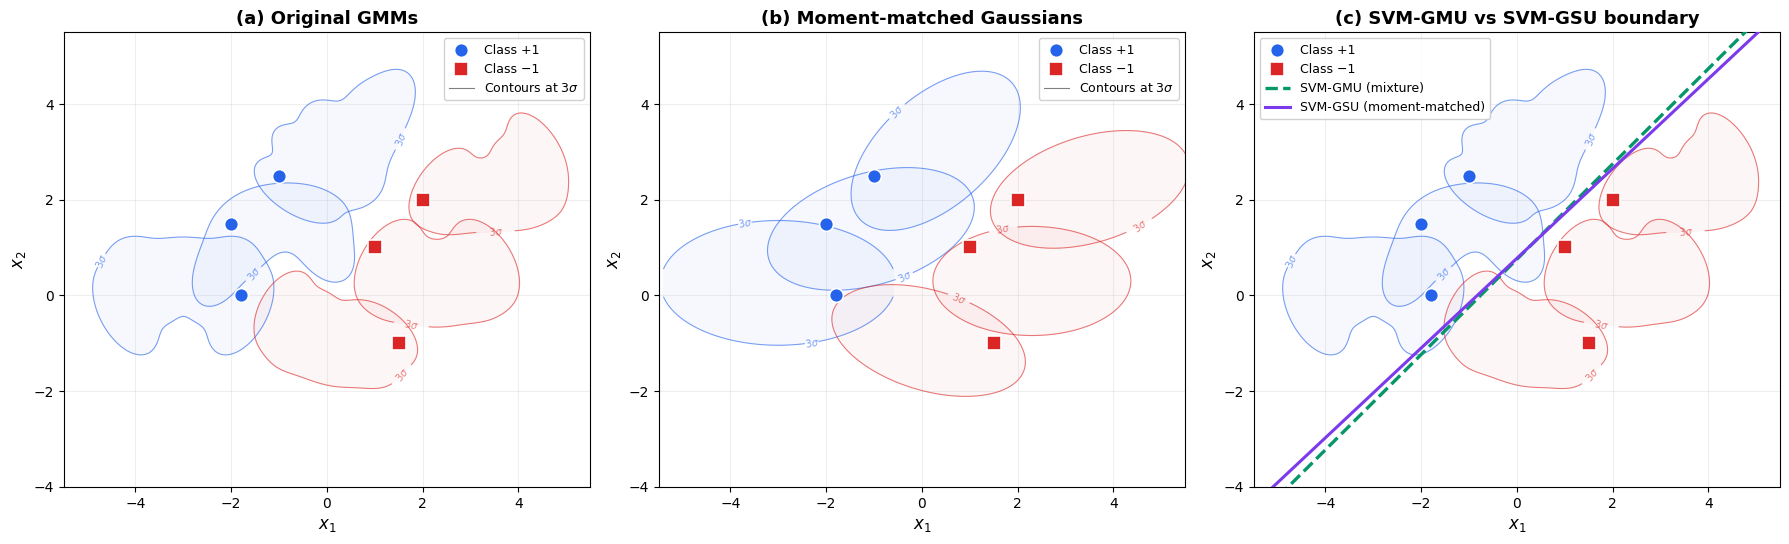

In [9]:
# Three-panel comparison figure.

n_rows, n_cols = 1, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.0 * n_cols, 6.0))

# Panel helper: give every panel the same axes limits so the shapes are
# directly comparable across panels.
XLIM = (-5.5, 5.5)
YLIM = (-4.0, 5.5)

# --- Panel (a): original GMM contours --------------------------------
plot_uncertainty(
    X, y, sample_uncertainty_gmu,
    sigmas=(3,),
    title="(a) Original GMMs",
    ax=axes[0],
)
axes[0].set_xlim(XLIM)
axes[0].set_ylim(YLIM)

# --- Panel (b): moment-matched single-Gaussian contours --------------
plot_uncertainty(
    X, y, sample_uncertainty_gsu,
    sigmas=(3,),
    title="(b) Moment-matched Gaussians",
    ax=axes[1],
)
axes[1].set_xlim(XLIM)
axes[1].set_ylim(YLIM)

# --- Panel (c): boundaries overlaid on original GMM contours ---------
plot_uncertainty(
    X, y, sample_uncertainty_gmu,
    sigmas=(3,),
    title="(c) SVM-GMU vs SVM-GSU boundary",
    ax=axes[2],
)

GMU_COLOR = "#059669"   # green, dashed (mixture-aware)
GSU_COLOR = "#7c3aed"   # purple, solid (single-Gaussian)


def _draw_line(ax, w, b, xlim, **kwargs):
    """Draw the line w^T x + b = 0 within the given x-limits."""
    xs = np.linspace(xlim[0], xlim[1], 400)
    if abs(w[1]) > 1e-8:
        ys = -(w[0] * xs + b) / w[1]
        return ax.plot(xs, ys, **kwargs)[0]
    x_vert = -b / w[0]
    return ax.axvline(x_vert, **kwargs)


ax = axes[2]
_draw_line(
    ax, model_gmu.coef_, float(model_gmu.intercept_), XLIM,
    color=GMU_COLOR, linewidth=2.4, linestyle="--", zorder=5,
    label="SVM-GMU (mixture)",
)
_draw_line(
    ax, model_gsu.coef_, float(model_gsu.intercept_), XLIM,
    color=GSU_COLOR, linewidth=2.2, linestyle="-", zorder=5,
    label="SVM-GSU (moment-matched)",
)
ax.set_xlim(XLIM)
ax.set_ylim(YLIM)

# Rebuild a clean legend on panel (c): keep the class-point entries that
# plot_uncertainty added, plus the two boundary entries we just added.
handles, labels = ax.get_legend_handles_labels()
keep_labels = {"Class +1", "Class \u22121",
               "SVM-GMU (mixture)", "SVM-GSU (moment-matched)"}
seen = set()
uniq = []
for h, l in zip(handles, labels):
    if l in keep_labels and l not in seen:
        seen.add(l)
        uniq.append((h, l))
ax.legend([h for h, _ in uniq], [l for _, l in uniq],
          loc="upper left", fontsize=9, framealpha=0.9)

fig.tight_layout()
plt.show()


## 7. Interpretation

Panel (b) already tells the cautionary tale without any classifier: each banana/crescent collapses to a tilted ellipse that covers roughly the same *area* but smears probability mass into regions the original GMM assigned little to. In other words, moment-matching preserves location and spread but throws away shape and curvature. For uncertainty distributions where the shape carries real information about where a point might actually be, this is a significant loss of fidelity.

Panel (c) shows how that loss of fidelity propagates to the learned classifier. The difference between the SVM-GMU boundary and the SVM-GSU boundary is exactly the value added by modeling the mixture structure directly rather than summarizing it. The metrics printed above (angle, offset, grid RMS) give a numeric handle on that difference.

On datasets where the per-sample uncertainty is genuinely unimodal and roughly elliptical, SVM-GSU and SVM-GMU will agree closely and the simpler GSU model suffices. The GMU generalization earns its keep on datasets like this one, where the uncertainty shape is multimodal or curved and a single ellipse is a poor stand-in.